In [1]:
##### Config #####
CONFIG_ROUNDS: int = 7
CONFIG_CLIENTS: int = 5
CONFIG_SHAP_SAMPLE: int = 25
##################

import os
# -------------------------
# Determinism / Reproducibility
# -------------------------
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except Exception:
    pass

# -------------------------
# Imports
# -------------------------
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap
import matplotlib.pyplot as plt
import warnings
import glob
import pandas as pd
import joblib
warnings.filterwarnings('ignore')

# =====================================================
# Federated XAI IDS (CNN + GRU Hybrid Version)
# =====================================================
class FederatedXAIIDS:
    def __init__(self, num_clients=5, input_dim=46, num_classes=6, batch_size=500000):
        self.num_clients = num_clients
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.batch_size = batch_size
        self.client_models = []
        self.global_model = None
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()

    # -----------------------------------------------------
    # CNN + GRU Model (Hybrid & Lightweight)
    # -----------------------------------------------------
    def create_model(self):
        model = keras.Sequential([
            layers.Reshape((self.input_dim, 1), input_shape=(self.input_dim,)),

            # CNN feature extractor (Spatial Features)
            layers.Conv1D(64, 3, activation='relu', padding='same'),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(128, 3, activation='relu', padding='same'),
            layers.Dropout(0.3),

            # GRU temporal feature extractor (Lightweight Sequential Modeling)
            layers.GRU(128, return_sequences=False),
            layers.Dropout(0.3),

            # Fully connected layers for classification
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    # -----------------------------------------------------
    # Process data files in batches
    # -----------------------------------------------------
    def process_files_in_batches(self, folder_path, file_pattern="*.csv", max_files=8, max_samples=None):
        print("Processing files for training...")

        csv_files = sorted(glob.glob(os.path.join(folder_path, file_pattern)))
        if not csv_files:
            raise ValueError(f"No CSV files found in {folder_path}")

        csv_files = csv_files[:max_files]
        print(f"Using {len(csv_files)} files for training.")

        print("Fitting preprocessing on sample data...")
        sample_data = self._get_sample_for_preprocessing(csv_files, sample_size=10000)
        self._fit_preprocessors(sample_data)

        all_client_data = {f'client_{i}': {'X_train': [], 'X_test': [], 'y_train': [], 'y_test': []}
                          for i in range(self.num_clients)}

        total_processed = 0

        for file_idx, csv_file in enumerate(csv_files):
            print(f"Processing file {file_idx+1}/{len(csv_files)}: {os.path.basename(csv_file)}")

            try:
                for chunk in pd.read_csv(csv_file, chunksize=self.batch_size, low_memory=False):
                    if max_samples and total_processed >= max_samples:
                        print(f"Reached maximum sample limit of {max_samples}")
                        break

                    X_processed, y_processed = self._process_chunk(chunk)
                    if X_processed is not None:
                        chunk_client_data = self._split_chunk_among_clients(X_processed, y_processed)
                        for client_id, data in chunk_client_data.items():
                            all_client_data[client_id]['X_train'].append(data['X_train'])
                            all_client_data[client_id]['X_test'].append(data['X_test'])
                            all_client_data[client_id]['y_train'].append(data['y_train'])
                            all_client_data[client_id]['y_test'].append(data['y_test'])
                        total_processed += len(X_processed)
                        print(f"  Processed {total_processed} samples so far...")
            except Exception as e:
                print(f"Error processing {csv_file}: {e}")
                continue

            if max_samples and total_processed >= max_samples:
                break

        # Combine chunks for each client
        final_client_data = []
        for client_id in range(self.num_clients):
            client_key = f'client_{client_id}'
            if (all_client_data[client_key]['X_train'] and
                len(all_client_data[client_key]['X_train'][0]) > 0):

                X_train = np.vstack(all_client_data[client_key]['X_train'])
                X_test = np.vstack(all_client_data[client_key]['X_test'])
                y_train = np.vstack(all_client_data[client_key]['y_train'])
                y_test = np.vstack(all_client_data[client_key]['y_test'])

                final_client_data.append({
                    'X_train': X_train,
                    'X_test': X_test,
                    'y_train': y_train,
                    'y_test': y_test
                })
                print(f"Client {client_id+1}: {len(X_train)} training, {len(X_test)} test samples")
            else:
                final_client_data.append({
                    'X_train': np.array([]).reshape(0, self.input_dim),
                    'X_test': np.array([]).reshape(0, self.input_dim),
                    'y_train': np.array([]).reshape(0, self.num_classes),
                    'y_test': np.array([]).reshape(0, self.num_classes)
                })
        print(f"Total processed samples: {total_processed}")
        return final_client_data

    # -----------------------------------------------------
    # Preprocessing helpers
    # -----------------------------------------------------
    def _get_sample_for_preprocessing(self, csv_files, sample_size=10000):
        sample_data, total_samples = [], 0
        for csv_file in csv_files:
            if total_samples >= sample_size:
                break
            try:
                df_sample = pd.read_csv(csv_file, nrows=min(2000, max(1, sample_size//len(csv_files))), low_memory=False)
                sample_data.append(df_sample)
                total_samples += len(df_sample)
            except Exception:
                continue
        if sample_data:
            return pd.concat(sample_data, ignore_index=True)
        else:
            raise ValueError("Could not load sample data for preprocessing")

    def _fit_preprocessors(self, sample_data):
        print("Fitting preprocessing objects...")
        sample_data = self._clean_data_chunk(sample_data)
        timestamp_cols = [c for c in sample_data.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            sample_data = sample_data.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(sample_data)
        X_sample = sample_data.drop(target_col, axis=1)
        y_sample = sample_data[target_col]
        self.input_dim = X_sample.shape[1]
        print(f"Input dimension set to: {self.input_dim}")
        y_sample = self._convert_to_six_classes(y_sample)
        self.scaler.fit(X_sample)
        self.label_encoder.fit(y_sample)
        print("Preprocessing objects fitted successfully")
        print(f"Classes: {list(self.label_encoder.classes_)}")

    def _process_chunk(self, chunk):
        chunk_clean = self._clean_data_chunk(chunk)
        if chunk_clean.empty:
            return None, None
        timestamp_cols = [c for c in chunk_clean.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            chunk_clean = chunk_clean.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(chunk_clean)
        X = chunk_clean.drop(target_col, axis=1)
        y = chunk_clean[target_col]
        y = self._convert_to_six_classes(y)
        X_processed = self.scaler.transform(X)
        y_encoded = self.label_encoder.transform(y)
        y_processed = keras.utils.to_categorical(y_encoded, self.num_classes)
        return X_processed, y_processed

    def _clean_data_chunk(self, df_chunk):
        for col in df_chunk.select_dtypes(include=['object']).columns:
            if col not in ['Label', 'label', 'attack', 'class']:
                try:
                    df_chunk[col] = pd.to_numeric(df_chunk[col], errors='coerce')
                except:
                    pass
        df_chunk = df_chunk.replace([np.inf, -np.inf], np.nan)
        df_chunk = df_chunk.dropna()
        return df_chunk

    def _identify_target_column(self, df):
        for c in ['label', 'Label', 'attack', 'Attack', 'class', 'Class']:
            if c in df.columns:
                return c
        return df.columns[-1]

    def _split_chunk_among_clients(self, X_chunk, y_chunk):
        chunk_size = len(X_chunk)
        if chunk_size == 0:
            return {}
        samples_per_client = chunk_size // self.num_clients
        client_data = {}
        for i in range(self.num_clients):
            start_idx, end_idx = i * samples_per_client, (i + 1) * samples_per_client
            if i == self.num_clients - 1:
                end_idx = chunk_size
            if start_idx < end_idx:
                X_client, y_client = X_chunk[start_idx:end_idx], y_chunk[start_idx:end_idx]
                if len(X_client) > 1:
                    X_train, X_test, y_train, y_test = train_test_split(
                        X_client, y_client, test_size=0.2, random_state=seed_value
                    )
                    client_data[f'client_{i}'] = {
                        'X_train': X_train,
                        'X_test': X_test,
                        'y_train': y_train,
                        'y_test': y_test
                    }
                else:
                    client_data[f'client_{i}'] = {
                        'X_train': X_client,
                        'X_test': np.array([]).reshape(0, self.input_dim),
                        'y_train': y_client,
                        'y_test': np.array([]).reshape(0, self.num_classes)
                    }
        return client_data

    def _convert_to_six_classes(self, y):
        y_str = y.astype(str).str.lower()
        class_mapping = {}
        for lbl in y_str.unique():
            lbl_low = lbl.lower()
            if any(k in lbl_low for k in ['benign', 'normal', 'legitimate']):
                class_mapping[lbl] = 'Benign'
            elif any(k in lbl_low for k in ['ddos', 'distributed denial']):
                class_mapping[lbl] = 'DDoS'
            elif any(k in lbl_low for k in ['dos', 'denial of service']):
                class_mapping[lbl] = 'DoS'
            elif 'mirai' in lbl_low:
                class_mapping[lbl] = 'Mirai'
            elif any(k in lbl_low for k in ['recon', 'scan', 'portscan', 'hostscan']):
                class_mapping[lbl] = 'Recon'
            else:
                class_mapping[lbl] = 'Other'
        return y_str.map(class_mapping)

    # -----------------------------------------------------
    # Federated Training
    # -----------------------------------------------------
    def federated_training(self, client_data, rounds=5, epochs=10):
        print("\nStarting Federated Training (CNN-GRU Hybrid Mode)...")
        self.global_model = self.create_model()
        global_weights = self.global_model.get_weights()
        accuracy_trends = {f'client_{i}': [] for i in range(self.num_clients)}

        for r in range(rounds):
            print(f"\n--- Federated Round {r+1} ---")
            client_weights, client_samples = [], []
            for i, data in enumerate(client_data):
                if len(data['X_train']) == 0:
                    print(f"Client {i+1}: No data, skipping...")
                    continue
                print(f"Training Client {i+1}...")
                local_model = self.create_model()
                local_model.set_weights(global_weights)
                history = local_model.fit(
                    data['X_train'], data['y_train'],
                    epochs=epochs, batch_size=256,
                    validation_data=(data['X_test'], data['y_test']),
                    verbose=0
                )
                acc = history.history['val_accuracy'][-1]
                accuracy_trends[f'client_{i}'].append(acc)
                client_weights.append(local_model.get_weights())
                client_samples.append(len(data['X_train']))
                print(f"Client {i+1} accuracy: {acc:.4f}")

            if client_weights:
                print("Aggregating weights with FedAvg...")
                new_global_weights = []
                total_samples = sum(client_samples)
                for weights in zip(*client_weights):
                    agg = np.zeros_like(weights[0])
                    for w, n in zip(weights, client_samples):
                        agg += w * (n / total_samples)
                    new_global_weights.append(agg)
                global_weights = new_global_weights
                self.global_model.set_weights(global_weights)

            global_acc = self.evaluate_global_model(client_data)
            print(f"Global model accuracy after round {r+1}: {global_acc:.4f}")
        return accuracy_trends

    # -----------------------------------------------------
    # Evaluate Global Model
    # -----------------------------------------------------
    def evaluate_global_model(self, client_data):
        X_test_all, y_test_all = [], []
        for d in client_data:
            if len(d['X_test']) > 0:
                X_test_all.append(d['X_test'])
                y_test_all.append(d['y_test'])
        if not X_test_all:
            return 0.0
        X_test, y_test = np.vstack(X_test_all), np.vstack(y_test_all)
        loss, acc = self.global_model.evaluate(X_test, y_test, verbose=0)
        return acc

    # -----------------------------------------------------
    # Train and Evaluate Loop
    # -----------------------------------------------------
    def train_and_evaluate(self, data_folder, file_pattern="*.csv"):
        client_data = self.process_files_in_batches(data_folder, file_pattern)
        accuracy_trends = self.federated_training(client_data, rounds=CONFIG_ROUNDS, epochs=10)

        print("\n" + "="*50)
        print("FINAL EVALUATION")
        print("="*50)
        final_acc = self.evaluate_global_model(client_data)
        print(f"Final Global Model Test Accuracy: {final_acc:.4f}")

        X_test_all, y_test_all = [], []
        for d in client_data:
            if len(d['X_test']) > 0:
                X_test_all.append(d['X_test'])
                y_test_all.append(d['y_test'])
        if X_test_all:
            X_test, y_test = np.vstack(X_test_all), np.vstack(y_test_all)
            y_pred = self.global_model.predict(X_test, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)
            y_true_classes = np.argmax(y_test, axis=1)
            print("\nClassification Report:")
            print(classification_report(y_true_classes, y_pred_classes, target_names=self.label_encoder.classes_))
            print(f"Overall Accuracy: {accuracy_score(y_true_classes, y_pred_classes):.4f}")

        # SHAP Explainability
        print("\n" + "="*60)
        print("🔍 Applying SHAP (Kernel SHAP) for Global Explainability")
        print("="*60)
        try:
            sample_size = min(CONFIG_SHAP_SAMPLE, X_test.shape[0])
            rng = np.random.default_rng(seed_value)
            shap_idx = rng.choice(X_test.shape[0], sample_size, replace=False)
            X_shap = X_test[shap_idx]
            background_size = min(100, X_test.shape[0])
            background_idx = rng.choice(X_test.shape[0], background_size, replace=False)
            X_bg = X_test[background_idx]
            explainer = shap.KernelExplainer(self.global_model.predict, X_bg)
            shap_vals = explainer.shap_values(X_shap, nsamples=100)
            shap.summary_plot(shap_vals, X_shap, show=False, plot_type="bar")
            plt.title("Global Feature Importance (SHAP - Kernel Explainer)")
            plt.tight_layout()
            plt.savefig("shap_global_feature_importance_bar.png")
            plt.close()
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.title("Global SHAP Summary (Feature Impact on Predictions)")
            plt.tight_layout()
            plt.savefig("shap_global_summary_dot.png")
            plt.close()
            print("📊 SHAP summary plots saved successfully.")
        except Exception as e:
            print(f"⚠️ SHAP explainability failed: {e}")

        return self.global_model, accuracy_trends

# =====================================================
# Main Execution Block
# =====================================================
if __name__ == "__main__":
    # Configured based on your Colab setup
    fed_xai_ids = FederatedXAIIDS(num_clients=CONFIG_CLIENTS, input_dim=46, num_classes=6, batch_size=500000)
    data_folder = r"." # Matches Colab root directory where train_data.csv is placed
    file_pattern = "train_data.csv"

    try:
        print("=== Federated CNN+GRU XAI IDS Training ===")
        print("Starting full-scale pipeline with GRU sequence extraction...")
        print("=" * 70)
        global_model, accuracy_trends = fed_xai_ids.train_and_evaluate(data_folder, file_pattern)

        # Save artifacts locally
        global_model.save("fedxaiids_CNNLSTM_TEST.h5")
        print("Model saved locally as 'fedxaiids_CNNLSTM_TEST.h5'")

        joblib.dump(fed_xai_ids.scaler, 'scaler_TEST.pkl')
        joblib.dump(fed_xai_ids.label_encoder, 'label_encoder_TEST.pkl')
        print("Preprocessing objects saved locally.")

        # =====================================================
        # 💾 GOOGLE DRIVE AUTO-BACKUP SYSTEM
        # =====================================================
        print("\n" + "="*50)
        print("📦 Backing up all artifacts to Google Drive...")
        print("="*50)
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=True)

            import shutil
            shutil.copy("fedxaiids_CNNLSTM_TEST.h5", "/content/drive/MyDrive/fedxaiids_CNNLSTM_TEST.h5")
            shutil.copy("scaler_TEST.pkl", "/content/drive/MyDrive/scaler_TEST.pkl")
            shutil.copy("label_encoder_TEST.pkl", "/content/drive/MyDrive/label_encoder_TEST.pkl")
            shutil.copy("shap_global_feature_importance_bar.png", "/content/drive/MyDrive/shap_global_feature_importance_bar.png")
            shutil.copy("shap_global_summary_dot.png", "/content/drive/MyDrive/shap_global_summary_dot.png")
            print("🚀 Backup completed successfully! All files are secured in Google Drive.")
        except Exception as drive_err:
            print(f"⚠️ Google Drive Backup failed: {drive_err}")
            print("Don't worry, files are still saved locally in Colab. Please download them manually.")

        print("\n" + "="*50)
        print("PROCESS COMPLETED SUCCESSFULLY!")
        print("="*50)
    except Exception as e:
        print(f"Error during execution: {e}")
        import traceback
        traceback.print_exc()

=== Federated CNN+GRU XAI IDS Training ===
Starting full-scale pipeline with GRU sequence extraction...
Processing files for training...
Using 1 files for training.
Fitting preprocessing on sample data...
Fitting preprocessing objects...
Input dimension set to: 46
Preprocessing objects fitted successfully
Classes: ['Benign', 'DDoS', 'DoS', 'Mirai', 'Other', 'Recon']
Processing file 1/1: train_data.csv
  Processed 218805 samples so far...
Client 1: 35008 training, 8753 test samples
Client 2: 35008 training, 8753 test samples
Client 3: 35008 training, 8753 test samples
Client 4: 35008 training, 8753 test samples
Client 5: 35008 training, 8753 test samples
Total processed samples: 218805

Starting Federated Training (CNN-GRU Hybrid Mode)...

--- Federated Round 1 ---
Training Client 1...
Client 1 accuracy: 0.8486
Training Client 2...
Client 2 accuracy: 0.8682
Training Client 3...
Client 3 accuracy: 0.8343
Training Client 4...
Client 4 accuracy: 0.8780
Training Client 5...
Client 5 accurac

  0%|          | 0/25 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
313/313 ━━━━━━

📊 SHAP summary plots saved successfully.
Model saved locally as 'fedxaiids_CNNLSTM_TEST.h5'
Preprocessing objects saved locally.

📦 Backing up all artifacts to Google Drive...
Mounted at /content/drive
🚀 Backup completed successfully! All files are secured in Google Drive.

PROCESS COMPLETED SUCCESSFULLY!


✅ Accuracy trends saved successfully to 'accuracy_trends.csv'


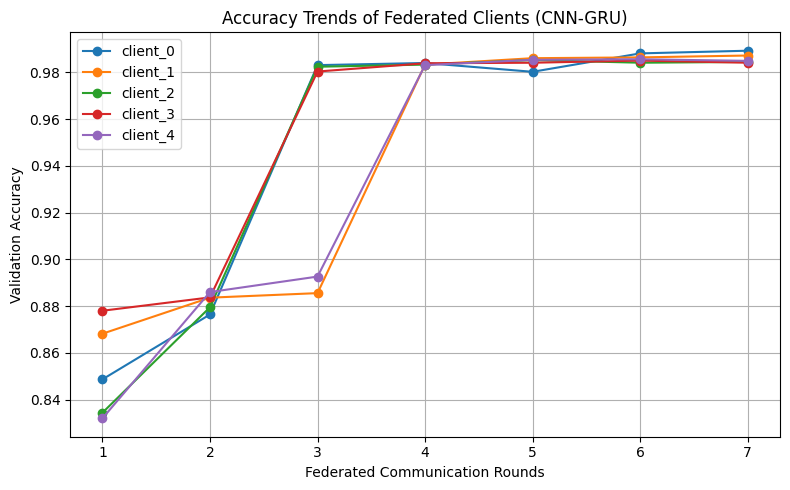

📈 Accuracy trends plot saved as 'accuracy_trends_plot.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ১. CSV ফাইল হিসেবে সেভ করা
accuracy_df = pd.DataFrame(accuracy_trends)
accuracy_df.to_csv('accuracy_trends.csv', index=False)
print("✅ Accuracy trends saved successfully to 'accuracy_trends.csv'")

# ২. অ্যাকুরেসি ট্রেন্ডের গ্রাফ (Line Plot) তৈরি এবং ছবি হিসেবে সেভ করা
plt.figure(figsize=(8, 5))
for client in accuracy_trends.keys():
    rounds_range = range(1, len(accuracy_trends[client]) + 1)
    plt.plot(rounds_range, accuracy_trends[client], marker='o', label=client)

plt.xlabel('Federated Communication Rounds')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy Trends of Federated Clients (CNN-GRU)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_trends_plot.png') # ইমেজ হিসেবে সেভ হবে
plt.show()
print("📈 Accuracy trends plot saved as 'accuracy_trends_plot.png'")


In [3]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import os

# =====================================================
# ১. সংরক্ষিত মডেল এবং প্রি-প্রসেসর লোড করা
# =====================================================
model_path = "fedxaiids_CNNLSTM_TEST.h5"
scaler_path = "scaler_TEST.pkl"
encoder_path = "label_encoder_TEST.pkl"

print("Loading saved artifacts...")
# compile=False ব্যবহার করা হয়েছে অপ্রয়োজনীয় ওয়ার্নিং এড়াতে
model = tf.keras.models.load_model(model_path, compile=False)
scaler = joblib.load(scaler_path)
label_encoder = joblib.load(encoder_path)

# ইনপুট ডাইমেনশন চেক করা
input_dim = model.input_shape[1]
print(f"✅ Model successfully loaded! It expects {input_dim} features per sample.")

# =====================================================
# ২. ইনপুট টেস্ট ডাটা সোর্স সেটআপ (test_data.csv)
# =====================================================
csv_file_path = "test_data.csv"

if not os.path.exists(csv_file_path):
    raise FileNotFoundError(f"⚠️ '{csv_file_path}' ফাইলটি কোলাব রুট ফোল্ডারে খুঁজে পাওয়া যায়নি!")

print(f"Reading real samples from: {csv_file_path}")
# প্রথম ৫টি লাইন রিড করা প্রেডিকশন করার জন্য
df_chunk = pd.read_csv(csv_file_path, nrows=5, low_memory=False)

# ডাটাস্ক্রিপ্টের ক্লিনিং রুটিন অনুসরণ করা
for col in df_chunk.select_dtypes(include=["object"]).columns:
    if col not in ["Label", "label", "attack", "class"]:
        df_chunk[col] = pd.to_numeric(df_chunk[col], errors="coerce")
df_chunk = df_chunk.replace([np.inf, -np.inf], np.nan).dropna()

# টাইমস্ট্যাম্প কলামগুলো ড্রপ করা
timestamp_cols = [c for c in df_chunk.columns if "time" in c.lower() or "timestamp" in c.lower()]
if timestamp_cols:
    df_chunk = df_chunk.drop(timestamp_cols, axis=1)

# টার্গেট কলাম (আসল লেবেল) সনাক্ত করা
target_col = next(
    (c for c in ["label", "Label", "attack", "Attack", "class", "Class"] if c in df_chunk.columns),
    df_chunk.columns[-1]
)

# তুলনা করার জন্য ডাটাসেটে থাকা আসল ক্লাসটি সংরক্ষণ করা
y_true_actual = df_chunk[target_col].values

# ফিচার ভ্যালুগুলো আলাদা করা
X_raw = df_chunk.drop(target_col, axis=1).values
print(f"Loaded {len(X_raw)} real sample(s) for testing.")

# =====================================================
# ৩. ডেটা প্রি-প্রসেস এবং ইনফ্যারেন্স (Prediction)
# =====================================================
# ধাপ ক: স্কেলার দিয়ে ডেটা স্ট্যান্ডার্ডাইজ করা
X_scaled = scaler.transform(X_raw)

# ধাপ খ: মডেল পাস করে প্রেডিকশন বের করা
raw_predictions = model.predict(X_scaled)

# ধাপ গ: সফ্টম্যাক্স আউটপুটকে টেক্সট ক্লাসে রূপান্তর করা
predicted_classes_idx = np.argmax(raw_predictions, axis=1)
predicted_labels = label_encoder.inverse_transform(predicted_classes_idx)

# =====================================================
# ৪. ফলাফল প্রদর্শন (Inference Output)
# =====================================================
print("\n" + "=" * 55)
print("🔍 INFERENCE RESULTS (DETECTION REPORT)")
print("=" * 55)
for i, (prob, pred_lbl, true_lbl) in enumerate(zip(raw_predictions, predicted_labels, y_true_actual)):
    print(f"Sample {i + 1}:")
    print(f"  -> Actual Class (Ground Truth) : {true_lbl}")
    print(f"  -> Predicted Class (AI Detection): {pred_lbl}")

    # প্রতি ক্লাসের প্রবাবিলিটি পার্সেন্টেজে সাজানো
    conf_details = ", ".join([f"{cls}: {p*100:.2f}%" for cls, p in zip(label_encoder.classes_, prob)])
    print(f"  -> Confidence Distribution      : {conf_details}")
    print("-" * 55)

Loading saved artifacts...
✅ Model successfully loaded! It expects 46 features per sample.
Reading real samples from: test_data.csv
Loaded 5 real sample(s) for testing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step

🔍 INFERENCE RESULTS (DETECTION REPORT)
Sample 1:
  -> Actual Class (Ground Truth) : DDoS-PSHACK_Flood
  -> Predicted Class (AI Detection): DDoS
  -> Confidence Distribution      : Benign: 0.00%, DDoS: 100.00%, DoS: 0.00%, Mirai: 0.00%, Other: 0.00%, Recon: 0.00%
-------------------------------------------------------
Sample 2:
  -> Actual Class (Ground Truth) : DDoS-PSHACK_Flood
  -> Predicted Class (AI Detection): DDoS
  -> Confidence Distribution      : Benign: 0.00%, DDoS: 100.00%, DoS: 0.00%, Mirai: 0.00%, Other: 0.00%, Recon: 0.00%
-------------------------------------------------------
Sample 3:
  -> Actual Class (Ground Truth) : DDoS-PSHACK_Flood
  -> Predicted Class (AI Detection): DDoS
  -> Confidence Distribution      : Benign: 0.00%, DDoS: 100.00%, DoS: 0.00%, Mirai: 0.